# M2. Personalización del entorno logístico RoboArena
Luis Tonchez, Desiderio Ortegon, Ayhan Ben Halima, Sebastian Martinez, Julian Bustos

El entorno usa un sistema de coordenadas bidimensional `(x, y)` en metros.
Cada elemento rectangular se representa como `(x, y, ancho, largo)`.


## 1. Librerías

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch
from matplotlib.lines import Line2D


## 2. Parámetros del entorno

Las medidas y posiciones principales se definen como parámetros para poder modificar la distribución sin reconstruir el programa.


In [ ]:
# Dimensiones generales de la nave (m)
WAREHOUSE_WIDTH = 26.0
WAREHOUSE_HEIGHT = 24.0

X_MIN = -WAREHOUSE_WIDTH / 2
X_MAX =  WAREHOUSE_WIDTH / 2
Y_MIN = -WAREHOUSE_HEIGHT / 2
Y_MAX =  WAREHOUSE_HEIGHT / 2

# Posiciones principales
PRODUCTION_X = [-6.0, -2.0, 2.0, 6.0]
RACK_ROWS_Y = [5.0, 0.0, -5.0]
DOCK_X = [-8.5, -3.0, 3.0, 8.5]

print(f"Nave: {WAREHOUSE_WIDTH} m x {WAREHOUSE_HEIGHT} m")


Nave: 26.0 m x 24.0 m


## 3. Definición de zonas y elementos

In [ ]:
def element(name, kind, x, y, w, h, traversable=False):
    return {
        "name": name,
        "type": kind,
        "x": float(x),
        "y": float(y),
        "w": float(w),
        "h": float(h),
        "traversable": bool(traversable)
    }

# Líneas de producción
production_lines = [
    element(f"PL{i+1}", "production", x, 9.4, 0.85, 3.4)
    for i, x in enumerate(PRODUCTION_X)
]

# Racks
racks = []
for i, y in enumerate(RACK_ROWS_Y, start=1):
    racks.append(element(f"Rack F{i}A", "rack", -1.5, y - 0.6, 10.8, 1.05))
    racks.append(element(f"Rack F{i}B", "rack", -1.5, y + 0.6, 10.8, 1.05))

racks += [
    element("Rack E1", "rack", 11.9, -2.5, 1.05, 5.4),
    element("Rack E2", "rack", 11.9,  4.0, 1.05, 5.4),
]

# Truck docks
truck_docks = [
    element(f"Dock D{i+1}", "dock", x, -10.85, 2.2, 2.0)
    for i, x in enumerate(DOCK_X)
]

# Estación de carga
charging_stations = [
    element("Estación de carga", "charging", 9.8, 9.4, 3.2, 2.2)
]

# Obstáculos
obstacles = [
    element("Obstáculo 1", "obstacle", -10.5, 5.0, 1.0, 2.0),
    element("Obstáculo 2", "obstacle", -10.5, 0.0, 1.0, 2.0),
    element("Obstáculo 3", "obstacle", -10.5, -5.0, 1.0, 2.0),
]

# Corredores / zonas transitables
corridors = [
    element("Pasillo norte", "corridor", 0.0, 7.0, 24.0, 1.5, True),
    element("Pasillo central 1", "corridor", 0.0, 2.5, 23.0, 2.0, True),
    element("Pasillo central 2", "corridor", 0.0, -2.5, 23.0, 2.0, True),
    element("Pasillo sur", "corridor", 0.0, -8.0, 24.0, 2.0, True),
    element("Pasillo este", "corridor", 9.5, 0.0, 2.0, 20.0, True),
]

# Posiciones destinadas a pallets
pallet_points = []

for i, x in enumerate(PRODUCTION_X, start=1):
    pallet_points.append({
        "name": f"Pallet PL{i}",
        "x": x + 1.4,
        "y": 9.4
    })

for i, x in enumerate(DOCK_X, start=1):
    pallet_points.append({
        "name": f"Pallet D{i}",
        "x": x,
        "y": -8.8
    })

all_elements = production_lines + racks + truck_docks + charging_stations + obstacles + corridors

print("Elementos definidos:", len(all_elements))
print("Puntos para pallets:", len(pallet_points))


Elementos definidos: 25
Puntos para pallets: 8


## 4. Tabla de coordenadas

In [ ]:
elements_df = pd.DataFrame(all_elements)
elements_df[["name", "type", "x", "y", "w", "h", "traversable"]]


,name,type,x,y,w,h,traversable
0,PL1,production,-6.0,9.40,0.85,3.40,False
1,PL2,production,-2.0,9.40,0.85,3.40,False
2,PL3,production,2.0,9.40,0.85,3.40,False
3,PL4,production,6.0,9.40,0.85,3.40,False
4,Rack F1A,rack,-1.5,4.40,10.80,1.05,False
5,Rack F1B,rack,-1.5,5.60,10.80,1.05,False
6,Rack F2A,rack,-1.5,-0.60,10.80,1.05,False
7,Rack F2B,rack,-1.5,0.60,10.80,1.05,False
8,Rack F3A,rack,-1.5,-5.60,10.80,1.05,False
9,Rack F3B,rack,-1.5,-4.40,10.80,1.05,False


## 5. Orígenes y destinos de los tres flujos logísticos

In [ ]:
rack_points = [
    {"name": "Rack F1", "x": 5.0, "y": 5.0},
    {"name": "Rack F2", "x": 5.0, "y": 0.0},
    {"name": "Rack F3", "x": 5.0, "y": -5.0},
    {"name": "Rack E1", "x": 10.8, "y": -2.5},
    {"name": "Rack E2", "x": 10.8, "y": 4.0},
]

production_points = [
    {"name": f"PL{i+1}", "x": x + 1.4, "y": 8.0}
    for i, x in enumerate(PRODUCTION_X)
]

dock_points = [
    {"name": f"D{i+1}", "x": x, "y": -9.2}
    for i, x in enumerate(DOCK_X)
]

flows = pd.DataFrame([
    {
        "Flujo": "Production Line → Rack / Truck Dock",
        "Origen": "Líneas de producción",
        "Destino": "Racks o truck docks"
    },
    {
        "Flujo": "Rack → Truck Dock",
        "Origen": "Racks",
        "Destino": "Truck docks"
    },
    {
        "Flujo": "Truck Dock → Rack",
        "Origen": "Truck docks",
        "Destino": "Racks"
    }
])

flows


,Flujo,Origen,Destino
0,Production Line → Rack / Truck Dock,Líneas de producción,Racks o truck docks
1,Rack → Truck Dock,Racks,Truck docks
2,Truck Dock → Rack,Truck docks,Racks


## 6. Visualización completa del entorno

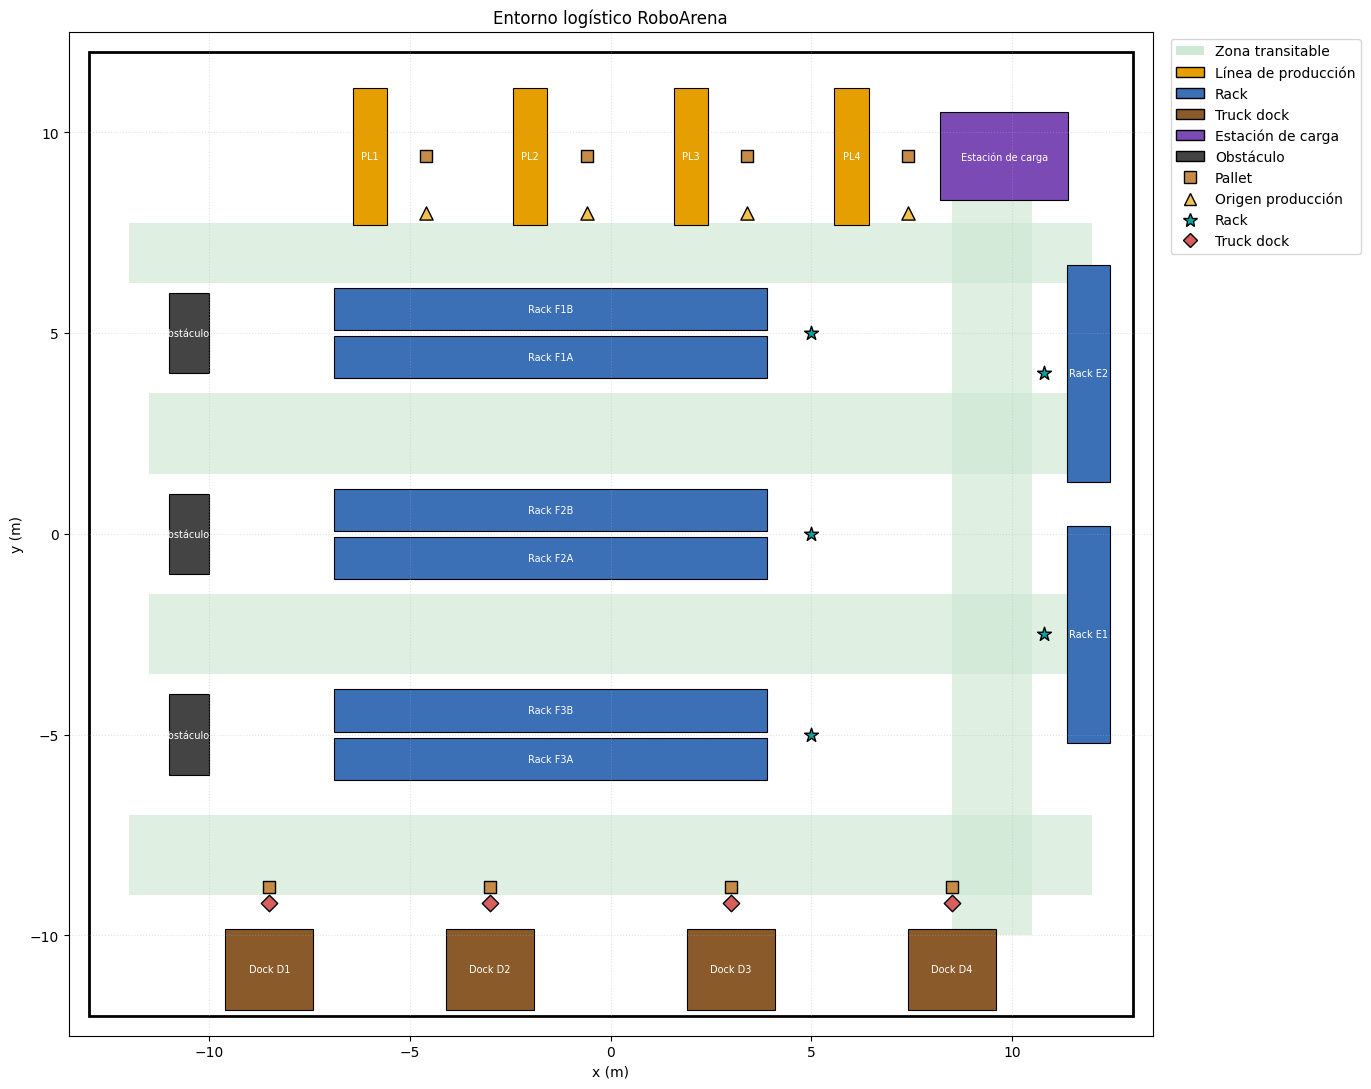

In [ ]:
# Dimensiones generales de la nave (m)
WAREHOUSE_WIDTH = 26.0
WAREHOUSE_HEIGHT = 24.0

X_MIN = -WAREHOUSE_WIDTH / 2
X_MAX =  WAREHOUSE_WIDTH / 2
Y_MIN = -WAREHOUSE_HEIGHT / 2
Y_MAX =  WAREHOUSE_HEIGHT / 2

# Posiciones principales
PRODUCTION_X = [-6.0, -2.0, 2.0, 6.0]
RACK_ROWS_Y = [5.0, 0.0, -5.0]
DOCK_X = [-8.5, -3.0, 3.0, 8.5]

def element(name, kind, x, y, w, h, traversable=False):
    return {
        "name": name,
        "type": kind,
        "x": float(x),
        "y": float(y),
        "w": float(w),
        "h": float(h),
        "traversable": bool(traversable)
    }

# Líneas de producción
production_lines = [
    element(f"PL{i+1}", "production", x, 9.4, 0.85, 3.4)
    for i, x in enumerate(PRODUCTION_X)
]

# Racks
racks = []
for i, y in enumerate(RACK_ROWS_Y, start=1):
    racks.append(element(f"Rack F{i}A", "rack", -1.5, y - 0.6, 10.8, 1.05))
    racks.append(element(f"Rack F{i}B", "rack", -1.5, y + 0.6, 10.8, 1.05))

racks += [
    element("Rack E1", "rack", 11.9, -2.5, 1.05, 5.4),
    element("Rack E2", "rack", 11.9,  4.0, 1.05, 5.4),
]

# Truck docks
truck_docks = [
    element(f"Dock D{i+1}", "dock", x, -10.85, 2.2, 2.0)
    for i, x in enumerate(DOCK_X)
]

# Estación de carga
charging_stations = [
    element("Estación de carga", "charging", 9.8, 9.4, 3.2, 2.2)
]

# Obstáculos
obstacles = [
    element("Obstáculo 1", "obstacle", -10.5, 5.0, 1.0, 2.0),
    element("Obstáculo 2", "obstacle", -10.5, 0.0, 1.0, 2.0),
    element("Obstáculo 3", "obstacle", -10.5, -5.0, 1.0, 2.0),
]

# Corredores / zonas transitables
corridors = [
    element("Pasillo norte", "corridor", 0.0, 7.0, 24.0, 1.5, True),
    element("Pasillo central 1", "corridor", 0.0, 2.5, 23.0, 2.0, True),
    element("Pasillo central 2", "corridor", 0.0, -2.5, 23.0, 2.0, True),
    element("Pasillo sur", "corridor", 0.0, -8.0, 24.0, 2.0, True),
    element("Pasillo este", "corridor", 9.5, 0.0, 2.0, 20.0, True),
]

# Posiciones destinadas a pallets
pallet_points = []

for i, x in enumerate(PRODUCTION_X, start=1):
    pallet_points.append({
        "name": f"Pallet PL{i}",
        "x": x + 1.4,
        "y": 9.4
    })

for i, x in enumerate(DOCK_X, start=1):
    pallet_points.append({
        "name": f"Pallet D{i}",
        "x": x,
        "y": -8.8
    })

rack_points = [
    {"name": "Rack F1", "x": 5.0, "y": 5.0},
    {"name": "Rack F2", "x": 5.0, "y": 0.0},
    {"name": "Rack F3", "x": 5.0, "y": -5.0},
    {"name": "Rack E1", "x": 10.8, "y": -2.5},
    {"name": "Rack E2", "x": 10.8, "y": 4.0},
]

production_points = [
    {"name": f"PL{i+1}", "x": x + 1.4, "y": 8.0}
    for i, x in enumerate(PRODUCTION_X)
]

dock_points = [
    {"name": f"D{i+1}", "x": x, "y": -9.2}
    for i, x in enumerate(DOCK_X)
]

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch
from matplotlib.lines import Line2D

COLORS = {
    "production": "#e69f00",
    "rack": "#3b6fb6",
    "dock": "#8b5a2b",
    "charging": "#7b4ab5",
    "obstacle": "#444444",
    "corridor": "#cfe8d5"
}

fig, ax = plt.subplots(figsize=(14, 11))

# Fondo del entorno
ax.add_patch(Rectangle(
    (X_MIN, Y_MIN),
    WAREHOUSE_WIDTH,
    WAREHOUSE_HEIGHT,
    facecolor="white",
    edgecolor="black",
    linewidth=2
))

# Corredores transitables
for e in corridors:
    ax.add_patch(Rectangle(
        (e["x"] - e["w"]/2, e["y"] - e["h"]/2),
        e["w"], e["h"],
        facecolor=COLORS["corridor"],
        edgecolor="none",
        alpha=0.65
    ))

# Elementos físicos
for e in production_lines + racks + truck_docks + charging_stations + obstacles:
    ax.add_patch(Rectangle(
        (e["x"] - e["w"]/2, e["y"] - e["h"]/2),
        e["w"], e["h"],
        facecolor=COLORS[e["type"]],
        edgecolor="black",
        linewidth=0.8
    ))
    ax.text(
        e["x"], e["y"], e["name"],
        ha="center", va="center",
        fontsize=7, color="white"
    )

# Pallets
for p in pallet_points:
    ax.scatter(
        p["x"], p["y"],
        marker="s", s=65,
        color="#c58b47",
        edgecolor="black",
        zorder=5
    )

# Puntos de origen/destino
for p in production_points:
    ax.scatter(p["x"], p["y"], marker="^", s=90, color="#f2c14e", edgecolor="black", zorder=6)

for p in rack_points:
    ax.scatter(p["x"], p["y"], marker="*", s=110, color="#00a6a6", edgecolor="black", zorder=6)

for p in dock_points:
    ax.scatter(p["x"], p["y"], marker="D", s=70, color="#d95f5f", edgecolor="black", zorder=6)

ax.set_xlim(X_MIN - 0.5, X_MAX + 0.5)
ax.set_ylim(Y_MIN - 0.5, Y_MAX + 0.5)
ax.set_aspect("equal")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title("Entorno logístico RoboArena")
ax.grid(True, linestyle=":", alpha=0.35)

legend_items = [
    Patch(facecolor=COLORS["corridor"], label="Zona transitable"),
    Patch(facecolor=COLORS["production"], edgecolor="black", label="Línea de producción"),
    Patch(facecolor=COLORS["rack"], edgecolor="black", label="Rack"),
    Patch(facecolor=COLORS["dock"], edgecolor="black", label="Truck dock"),
    Patch(facecolor=COLORS["charging"], edgecolor="black", label="Estación de carga"),
    Patch(facecolor=COLORS["obstacle"], edgecolor="black", label="Obstáculo"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor="#c58b47",
           markeredgecolor="black", markersize=8, label="Pallet"),
    Line2D([0], [0], marker="^", color="w", markerfacecolor="#f2c14e",
           markeredgecolor="black", markersize=8, label="Origen producción"),
    Line2D([0], [0], marker="*", color="w", markerfacecolor="#00a6a6",
           markeredgecolor="black", markersize=10, label="Rack"),
    Line2D([0], [0], marker="D", color="w", markerfacecolor="#d95f5f",
           markeredgecolor="black", markersize=7, label="Truck dock"),
]

ax.legend(handles=legend_items, loc="upper left", bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.savefig("roboarena_entorno_limpio.png", dpi=200, bbox_inches="tight")
plt.show()

## 7. Análisis breve

### 1. ¿Cómo representaron computacionalmente el entorno?
Representamos la nave como un plano de 26 × 24 metros con coordenadas `(x, y)`. Cada elemento tiene una posición, ancho, largo y tipo.

### 2. ¿Qué elementos incluyeron?
Incluimos líneas de producción, racks, truck docks, una estación de carga, posiciones para pallets, corredores transitables y obstáculos.

### 3. ¿Qué características personalizaron respecto al ejemplo mostrado en clase?
Personalizamos las dimensiones del espacio, la posición de los racks, las líneas de producción, los truck docks, la estación de carga, los pallets, los corredores y los obstáculos.

### 4. ¿Por qué eligieron esa distribución?
Elegimos esta distribución para separar las áreas de producción, almacenamiento y carga o descarga, dejando pasillos para circulación.

### 5. ¿Cómo representaron las zonas transitables y los obstáculos?
Las zonas transitables se representan como corredores y los obstáculos como rectángulos que no se pueden atravesar.

### 6. ¿Dónde se encuentran los posibles orígenes y destinos de los tres flujos logísticos?
El flujo **Production Line → Rack / Truck Dock** inicia en las líneas de producción y termina en racks o truck docks. El flujo **Rack → Truck Dock** inicia en los racks y termina en los truck docks. El flujo **Truck Dock → Rack** inicia en los truck docks y termina en los racks.

### 7. ¿Qué elementos de este entorno consideran que serán importantes cuando posteriormente se incorpore la lógica de los AGVs?
Serán importantes las coordenadas de origen y destino, los pasillos transitables, los obstáculos, los pallets, los racks, los truck docks y la estación de carga.


# M3. Sistema Multiagente de AGVs en el entorno RoboArena
Luis Tonchez, Desiderio Ortegon, Ayhan Ben Halima, Sebastian Martinez, Julian Bustos

Esta segunda entrega extiende el entorno logístico personalizado desarrollado en M2 (secciones 1 a 7, arriba)
incorporando una flota de **AGV autónomos** que operan sobre ese mismo entorno como un **Sistema Multiagente (SMA)**.

En esta etapa **no** se implementa Q-Learning, MDP ni optimización avanzada — esas técnicas se abordarán en la
siguiente actividad. El objetivo de M3 es demostrar que la arquitectura fundamental de un SMA funciona:

- Cada AGV es un agente independiente con estado propio (posición, batería, misión actual, pallet transportado, etc.).
- Existen pallets y misiones de transporte, publicadas por un Mission Manager de rol limitado.
- Los AGV se comunican mediante un mecanismo explícito (mensajes/blackboard) y **negocian** entre ellos —
  mediante una regla simple de puja (bidding) — quién ejecuta cada misión, sin que un componente central asigne
  las misiones.
- El sistema exhibe colaboración básica (evitar dobles aceptaciones, respetar disponibilidad/batería, permitir que
  un AGV disponible tome una misión que otro no puede atender) y evoluciona dinámicamente durante muchos pasos de
  simulación, con una animación del almacén.

## M3.1 Librerías adicionales

In [ ]:
import random
import heapq
import math
import matplotlib
import matplotlib.animation as animation
from IPython.display import HTML, display

random.seed(11)
matplotlib.rcParams['animation.embed_limit'] = 80  # MB, margen para la animación embebida

print("Librerías adicionales cargadas.")

## M3.2 Rejilla de navegación sobre el entorno M2

Para que los AGV respeten las principales áreas transitables y no transitables definidas en M2, construimos una
rejilla (grid) discreta de 1 m de resolución sobre la nave y aplicamos búsqueda de ruta A* (equivalente a distancia
Manhattan en una rejilla de 4 direcciones). Una celda es transitable si:

1. su centro cae dentro de un **corredor** (`traversable=True` en M2), o
2. está dentro de un radio de acercamiento (`ACCESS_RADIUS`) de un punto de interacción (líneas de producción,
   racks, docks, estación de carga, posiciones de pallet) — esto permite que un AGV se "arrime" al punto exacto
   de recogida/entrega desde el corredor más cercano;

y **nunca** si cae dentro de un obstáculo, sin importar lo anterior (regla dura).

Esto no pretende ser un algoritmo de ruteo sofisticado (fuera de alcance de M3): la calidad del ruteo no se evalúa
en esta actividad. Lo importante es que el **mecanismo de negociación decide qué AGV ejecuta una misión**, mientras
que esta rejilla + A* solo decide **cómo** llega dicho AGV a su destino.

In [ ]:
GRID_RES = 1.0        # metros por celda
ACCESS_RADIUS = 2.0    # metros alrededor de puntos de interacción


def build_grid(x_min, x_max, y_min, y_max, corridors_, obstacles_, interaction_points, res=GRID_RES, access_radius=ACCESS_RADIUS):
    xs = np.arange(x_min, x_max + res, res)
    ys = np.arange(y_min, y_max + res, res)
    nx, ny = len(xs), len(ys)
    walkable = np.zeros((nx, ny), dtype=bool)
    for i, cx in enumerate(xs):
        for j, cy in enumerate(ys):
            ok = False
            for c in corridors_:
                if abs(cx - c["x"]) <= c["w"] / 2 and abs(cy - c["y"]) <= c["h"] / 2:
                    ok = True
                    break
            if not ok:
                for p in interaction_points:
                    if (cx - p["x"]) ** 2 + (cy - p["y"]) ** 2 <= access_radius ** 2:
                        ok = True
                        break
            if ok:
                for o in obstacles_:
                    if abs(cx - o["x"]) <= o["w"] / 2 and abs(cy - o["y"]) <= o["h"] / 2:
                        ok = False
                        break
            walkable[i, j] = ok
    return xs, ys, walkable


class GridNav:
    # Rejilla de navegación + búsqueda de ruta A* (4 direcciones ~ Manhattan).

    def __init__(self, x_min, x_max, y_min, y_max, corridors_, obstacles_, interaction_points,
                 res=GRID_RES, access_radius=ACCESS_RADIUS):
        self.res = res
        self.xs, self.ys, self.walkable = build_grid(
            x_min, x_max, y_min, y_max, corridors_, obstacles_, interaction_points, res, access_radius
        )
        self.nx, self.ny = len(self.xs), len(self.ys)

    def nearest_cell(self, x, y):
        i = int(np.clip(round((x - self.xs[0]) / self.res), 0, self.nx - 1))
        j = int(np.clip(round((y - self.ys[0]) / self.res), 0, self.ny - 1))
        if self.walkable[i, j]:
            return i, j
        best, best_d = None, None
        for r in range(1, max(self.nx, self.ny)):
            for di in range(-r, r + 1):
                for dj in range(-r, r + 1):
                    ii, jj = i + di, j + dj
                    if 0 <= ii < self.nx and 0 <= jj < self.ny and self.walkable[ii, jj]:
                        d = di * di + dj * dj
                        if best_d is None or d < best_d:
                            best_d, best = d, (ii, jj)
            if best is not None:
                return best
        return (i, j)

    def cell_to_xy(self, i, j):
        return float(self.xs[i]), float(self.ys[j])

    def astar(self, start_xy, goal_xy):
        start = self.nearest_cell(*start_xy)
        goal = self.nearest_cell(*goal_xy)
        if start == goal:
            return [self.cell_to_xy(*start)]

        def h(a, b):
            return abs(a[0] - b[0]) + abs(a[1] - b[1])

        open_set = [(h(start, goal), 0, start, None)]
        came_from, gscore, visited = {}, {start: 0}, set()
        neighbors = [(-1, 0), (1, 0), (0, -1), (0, 1)]
        while open_set:
            _, g, current, parent = heapq.heappop(open_set)
            if current in visited:
                continue
            visited.add(current)
            came_from[current] = parent
            if current == goal:
                path, node = [], current
                while node is not None:
                    path.append(node)
                    node = came_from[node]
                path.reverse()
                return [self.cell_to_xy(i, j) for (i, j) in path]
            for di, dj in neighbors:
                ni, nj = current[0] + di, current[1] + dj
                if 0 <= ni < self.nx and 0 <= nj < self.ny and self.walkable[ni, nj]:
                    ng = g + 1
                    if (ni, nj) not in gscore or ng < gscore[(ni, nj)]:
                        gscore[(ni, nj)] = ng
                        heapq.heappush(open_set, (ng + h((ni, nj), goal), ng, (ni, nj), current))
        return [start_xy, goal_xy]  # sin ruta -> línea recta de respaldo (no debería ocurrir)


charging_xy = (charging_stations[0]["x"], charging_stations[0]["y"])

interaction_points = (
    production_points + rack_points + dock_points + pallet_points
    + [{"name": "Charging", "x": charging_xy[0], "y": charging_xy[1]}]
)

nav = GridNav(X_MIN, X_MAX, Y_MIN, Y_MAX, corridors, obstacles, interaction_points)
print(f"Rejilla: {nav.nx} x {nav.ny} celdas ({GRID_RES} m/celda), transitables: {nav.walkable.sum()}")

## M3.3 Posiciones de almacenamiento de pallets

Es importante distinguir el **rack** (infraestructura fija del almacén, ya definida en M2) de la **posición de
almacenamiento de pallet** (un slot puntual que puede estar ocupado o vacío). Generamos 3 posiciones de
almacenamiento por cada rack de M2 (`rack_points`), desplazadas a lo largo del rack.

In [ ]:
def build_storage_slots():
    slots = []
    horizontal_racks = {"Rack F1", "Rack F2", "Rack F3"}
    for rp in rack_points:
        is_horizontal = rp["name"] in horizontal_racks
        for k in range(3):
            offset = (k - 1) * 1.0
            if is_horizontal:
                slots.append({"slot_id": f"{rp['name']}-S{k+1}", "x": rp["x"] + offset, "y": rp["y"], "rack": rp["name"]})
            else:
                slots.append({"slot_id": f"{rp['name']}-S{k+1}", "x": rp["x"], "y": rp["y"] + offset, "rack": rp["name"]})
    return slots


STORAGE_SLOTS = build_storage_slots()
# las posiciones de almacenamiento también deben ser transitables/alcanzables por los AGV
nav = GridNav(X_MIN, X_MAX, Y_MIN, Y_MAX, corridors, obstacles, interaction_points + STORAGE_SLOTS)

slots_df = pd.DataFrame(STORAGE_SLOTS)
print("Posiciones de almacenamiento generadas:", len(STORAGE_SLOTS))
slots_df.head(9)

## M3.4 Modelo de datos: Pallet y Misión

**Pallet**: objeto físico transportable. Mantiene identificador, posición actual y estado
(`almacenado` → `esperando_recogida` → `reservado` → `en_transporte` → `entregado`).

**Mission** (misión de transporte): referencia al pallet, punto de recogida, punto de entrega, tipo de flujo
logístico (de los tres definidos en M2: Producción→Rack/Dock, Rack→Dock, Dock→Rack), prioridad y estado
(`pendiente` → `publicada` → `reservada` → `en_progreso` → `completada`).

In [ ]:
class Pallet:
    def __init__(self, pallet_id, x, y, home_slot=None):
        self.pallet_id = pallet_id
        self.x = x
        self.y = y
        self.home_slot = home_slot
        self.status = "almacenado"  # almacenado/esperando_recogida/reservado/en_transporte/entregado
        self.destination_label = None

    @property
    def position(self):
        return (self.x, self.y)


class Mission:
    _counter = 1

    def __init__(self, pallet, dropoff_xy, dropoff_label, flow_label, step, priority):
        self.mission_id = f"M{Mission._counter:02d}"
        Mission._counter += 1
        self.pallet_id = pallet.pallet_id
        self.pickup_xy = pallet.position
        self.dropoff_xy = dropoff_xy
        self.dropoff_label = dropoff_label
        self.flow_label = flow_label
        self.priority = priority
        self.status = "pendiente"
        self.created_step = step
        self.assigned_agv = None


print("Clases Pallet y Mission definidas.")

## M3.5 Comunicación: mensajes y bus compartido (blackboard)

La comunicación se representa computacionalmente mediante una clase `Message` (quién envía, quién recibe —`ALL`
para difusión/broadcast—, tipo de mensaje y contenido) y una clase `MessageBus` que actúa como **tablero
compartido**: todos los AGV pueden "ver" los mensajes que otros agentes publican (por ejemplo, las pujas de una
negociación), igual que en un blackboard system.

Tipos de mensaje usados:

| Mensaje | Emisor | Receptor | Contenido | Cómo lo usa el receptor |
|---|---|---|---|---|
| `MISSION_PUBLISHED` | Mission Manager | todos los AGV | misión, flujo, prioridad | cada AGV evalúa si le conviene pujar |
| `BID` | AGV | todos (blackboard) | misión, valor de la puja | cada AGV compara su puja contra las demás para autoseleccionarse |
| `NOT_AVAILABLE` | AGV | todos | misión, motivo (ocupado / batería baja) | informa a los demás que ese AGV no compite |
| `MISSION_ACCEPTED` | AGV ganador | todos | misión | los demás AGV descartan esa misión de sus candidatas |
| `ARRIVED_PICKUP` | AGV | Mission Manager | misión, pallet | registro de progreso |
| `PALLET_LOADED` | AGV | todos | pallet, destino | informa que el pallet ya está en tránsito |
| `MISSION_COMPLETED` | AGV | Mission Manager | misión | Mission Manager cierra la misión |
| `BATTERY_LOW` | AGV | todos | nivel de batería | informa que ese AGV dejará de pujar y va a recargar |
| `CHARGE_DONE` | AGV | todos | nivel de batería | informa que ese AGV vuelve a estar disponible |

In [ ]:
NARRATIVE = {
    "MISSION_PUBLISHED": lambda c: f"Misión {c['mission_id']} publicada ({c['flow_label']}, prioridad {c['priority']})",
    "BID": lambda c: f"{c['agv_id']} puja por {c['mission_id']}: {c['bid']}",
    "NOT_AVAILABLE": lambda c: f"{c['agv_id']} no disponible para {c['mission_id']} ({c['reason']})",
    "MISSION_ACCEPTED": lambda c: f"{c['agv_id']} acepta la {c['mission_id']}",
    "ARRIVED_PICKUP": lambda c: f"{c['agv_id']} llegó al pallet {c['pallet_id']}",
    "PALLET_LOADED": lambda c: f"{c['agv_id']} transportando {c['pallet_id']} -> {c['dropoff_label']}",
    "MISSION_COMPLETED": lambda c: f"{c['agv_id']} completó la {c['mission_id']}",
    "BATTERY_LOW": lambda c: f"{c['agv_id']} batería baja ({c['battery']:.0f}%), regresa a recargar",
    "CHARGE_DONE": lambda c: f"{c['agv_id']} recarga completa ({c['battery']:.0f}%), disponible",
}


class Message:
    def __init__(self, step, sender, receiver, mtype, content):
        self.step, self.sender, self.receiver = step, sender, receiver
        self.mtype, self.content = mtype, content

    def __str__(self):
        fn = NARRATIVE.get(self.mtype)
        text = fn(self.content) if fn else f"{self.sender}->{self.receiver}: {self.mtype} {self.content}"
        return f"[t={self.step:03d}] {text}"


class MessageBus:
    def __init__(self):
        self.messages = []

    def broadcast(self, sender, mtype, content, step):
        content = dict(content); content.setdefault("agv_id", sender)
        msg = Message(step, sender, "ALL", mtype, content)
        self.messages.append(msg)
        return msg

    def send(self, sender, receiver, mtype, content, step):
        content = dict(content); content.setdefault("agv_id", sender)
        msg = Message(step, sender, receiver, mtype, content)
        self.messages.append(msg)
        return msg

    def as_text(self):
        return [str(m) for m in self.messages]


print("Mecanismo de comunicación (Message / MessageBus) definido.")

## M3.6 Mission Manager (rol limitado)

El `MissionManager` **solo** administra el ciclo de vida de las misiones: mantiene la lista de misiones
pendientes/abiertas, publica nuevas misiones (broadcast) y registra aceptaciones y finalizaciones. **No** decide
qué AGV ejecuta cada misión — esa decisión surge de la negociación entre los propios AGV (sección M3.7).

In [ ]:
class MissionManager:
    def __init__(self, bus_):
        self.bus = bus_
        self.open_missions = []          # publicadas, aún no reservadas por ningún AGV
        self.in_progress_missions = []
        self.completed_missions = []

    def publish(self, mission, step):
        mission.status = "publicada"
        self.open_missions.append(mission)
        self.bus.broadcast(
            "MissionManager", "MISSION_PUBLISHED",
            {"mission_id": mission.mission_id, "flow_label": mission.flow_label, "priority": mission.priority},
            step,
        )

    def register_acceptance(self, mission):
        if mission in self.open_missions:
            self.open_missions.remove(mission)
        self.in_progress_missions.append(mission)

    def register_completion(self, mission):
        if mission in self.in_progress_missions:
            self.in_progress_missions.remove(mission)
        self.completed_missions.append(mission)


print("Mission Manager (rol limitado) definido.")

## M3.7 Agente AGV: estado interno, batería, negociación y colaboración

**Estado interno de cada AGV** (mínimo requerido, más algunos campos adicionales):

- `agv_id`: identificador único (`AGV-1`, `AGV-2`, ...).
- `x, y`: posición actual.
- `state`: `IDLE`, `MOVING_TO_PICKUP`, `MOVING_TO_DROPOFF`, `RETURNING_TO_CHARGE`, `CHARGING`.
- `battery`: nivel de batería (0-100%).
- `carried_pallet`: id del pallet transportado (o `None`).
- `current_mission`: id de la misión actual (o `None`).
- `missions_completed`, `distance_traveled`: métricas acumuladas.

**Negociación (bidding).** Cuando el Mission Manager publica una misión, cada AGV *disponible*
(`state == IDLE` y `battery` por encima del umbral de batería baja) calcula su propia puja con la regla de
utilidad:

$$\text{puja} = 100 - 1.8 \cdot d_{Manhattan}(AGV, pickup) + 0.2 \cdot bateria + 10 \cdot prioridad$$

Es decir: **a menor distancia al punto de recogida, mayor batería disponible y mayor prioridad de la misión,
mayor la puja**. Cada AGV publica su puja en el tablero compartido (`MessageBus`). La resolución sigue una
variante simplificada del **Contract Net Protocol**: cada AGV que participó compara su propia puja contra todas
las pujas visibles en el tablero (método `wins_negotiation`) y **se autoselecciona** si la suya es la máxima
(con desempate determinístico por id de AGV). El AGV ganador reserva la misión de inmediato y difunde
`MISSION_ACCEPTED`; los demás simplemente descartan esa misión — el Mission Manager no interviene en la elección.

**Colaboración básica** (todas verificables en el log de la sección M3.10):

- Un AGV ocupado (`state != IDLE`) nunca puja → no puede competir por una nueva misión mientras ejecuta otra.
- Un AGV con batería baja tampoco puja, y en cambio se dirige a la estación de carga → nunca acepta una misión
  si necesita recargarse.
- En cuanto un AGV reserva una misión, ésta se retira de `open_missions` → ningún otro AGV puede aceptarla después
  (evita doble aceptación).
- Si un AGV está ocupado o con batería baja, los demás AGV disponibles pujan igualmente por la misión publicada →
  un AGV disponible puede tomar una misión que otro no puede atender.
- Cada cambio de disponibilidad (batería baja, recarga completa, misión aceptada/],completada) se comunica por
  broadcast, de forma que el resto de agentes conoce el estado actualizado del sistema.

In [ ]:
LOW_BATTERY_THRESHOLD = 25.0     # bajo este nivel, el AGV deja de pujar y regresa a recargar
CHARGE_FULL_LEVEL = 95.0
BATTERY_DRAIN_PER_CELL = 0.55    # % de batería por celda de rejilla recorrida
BATTERY_CHARGE_PER_STEP = 10.0   # % de batería recuperada por paso en la estación de carga


def manhattan(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])


class AGV:
    def __init__(self, agv_id, start_xy, nav_, charging_xy_, battery=100.0):
        self.agv_id = agv_id
        self.x, self.y = start_xy
        self.nav = nav_
        self.charging_xy = charging_xy_
        self.battery = battery
        self.state = "IDLE"
        self.path = []
        self.carried_pallet = None
        self.current_mission = None
        self.missions_completed = 0
        self.distance_traveled = 0.0

    @property
    def position(self):
        return (self.x, self.y)

    # negociación
    def is_available_for_bid(self):
        return self.state == "IDLE" and self.battery > LOW_BATTERY_THRESHOLD

    def compute_bid(self, mission):
        dist = manhattan(self.position, mission.pickup_xy)
        utility = 100.0 - 1.8 * dist + 0.2 * self.battery + mission.priority * 10.0
        return round(utility, 1)

    def wins_negotiation(self, bids):
        # Cada AGV decide por sí mismo, comparando su puja contra el tablero
        # compartido de pujas (bids), si es el ganador (mayor puja; empate -> id menor).
        ranked = sorted(bids.items(), key=lambda kv: (-kv[1], kv[0]))
        return ranked[0][0] == self.agv_id

    def accept_mission(self, mission, pallets_, bus_, mission_manager_, step):
        self.state = "MOVING_TO_PICKUP"
        self.current_mission = mission.mission_id
        mission.status = "reservada"
        mission.assigned_agv = self.agv_id
        pallets_[mission.pallet_id].status = "reservado"
        mission_manager_.register_acceptance(mission)
        self._set_path_to(mission.pickup_xy)
        bus_.broadcast("MissionManager", "MISSION_ACCEPTED", {"agv_id": self.agv_id, "mission_id": mission.mission_id}, step)

    #movimiento
    def _set_path_to(self, target_xy):
        full = self.nav.astar(self.position, target_xy)
        self.path = full[1:] if len(full) > 1 else []

    def _advance(self):
        if not self.path:
            return False
        nxt = self.path.pop(0)
        d = manhattan(self.position, nxt)
        self.distance_traveled += d
        self.battery = max(0.0, self.battery - BATTERY_DRAIN_PER_CELL * d)
        self.x, self.y = nxt
        return True

    #actualización por paso de simulación
    def update(self, step, pallets_, missions_by_id_, bus_, mission_manager_):
        if self.state == "IDLE":
            if self.battery <= LOW_BATTERY_THRESHOLD:
                self.state = "RETURNING_TO_CHARGE"
                self._set_path_to(self.charging_xy)
                bus_.broadcast(self.agv_id, "BATTERY_LOW", {"battery": self.battery}, step)
            return

        if self.state == "MOVING_TO_PICKUP":
            moved = self._advance()
            if not moved:
                mission = missions_by_id_[self.current_mission]
                pallet = pallets_[mission.pallet_id]
                bus_.send(self.agv_id, "MissionManager", "ARRIVED_PICKUP",
                          {"pallet_id": pallet.pallet_id, "mission_id": mission.mission_id}, step)
                pallet.status = "en_transporte"
                self.carried_pallet = pallet.pallet_id
                mission.status = "en_progreso"
                self.state = "MOVING_TO_DROPOFF"
                self._set_path_to(mission.dropoff_xy)
                bus_.broadcast(self.agv_id, "PALLET_LOADED",
                               {"pallet_id": pallet.pallet_id, "dropoff_label": mission.dropoff_label}, step)
            return

        if self.state == "MOVING_TO_DROPOFF":
            mission = missions_by_id_[self.current_mission]
            pallet = pallets_[mission.pallet_id]
            moved = self._advance()
            if self.carried_pallet:
                pallet.x, pallet.y = self.position
            if not moved:
                pallet.status = "entregado"
                mission.status = "completada"
                mission_manager_.register_completion(mission)
                self.missions_completed += 1
                self.carried_pallet = None
                self.current_mission = None
                bus_.broadcast(self.agv_id, "MISSION_COMPLETED", {"mission_id": mission.mission_id}, step)
                if self.battery <= LOW_BATTERY_THRESHOLD:
                    self.state = "RETURNING_TO_CHARGE"
                    self._set_path_to(self.charging_xy)
                    bus_.broadcast(self.agv_id, "BATTERY_LOW", {"battery": self.battery}, step)
                else:
                    self.state = "IDLE"
            return

        if self.state == "RETURNING_TO_CHARGE":
            moved = self._advance()
            if not moved:
                self.state = "CHARGING"
            return

        if self.state == "CHARGING":
            self.battery = min(100.0, self.battery + BATTERY_CHARGE_PER_STEP)
            if self.battery >= CHARGE_FULL_LEVEL:
                self.state = "IDLE"
                bus_.broadcast(self.agv_id, "CHARGE_DONE", {"battery": self.battery}, step)
            return


print("Clase AGV (agente autónomo) definida.")

## M3.8 Configuración de la simulación

Se crean **4 AGV** con posiciones iniciales e identificadores distintos y niveles de batería distintos, un lote
inicial de **pallets almacenados** en posiciones de rack, y un **generador dinámico de misiones** que cubre los
tres flujos logísticos definidos en M2 (Producción→Rack, Rack→Dock, Dock→Rack). Las misiones se publican en
distintos pasos de tiempo (no todas al inicio) para demostrar que el sistema responde a eventos dinámicos.

In [ ]:
N_AGVS = 4
N_STEPS = 140
INITIAL_STORED_PALLETS = 6

# pallets iniciales, almacenados en posiciones de rack
pallets = {}
occupied_slots = set()
slot_pool = STORAGE_SLOTS.copy()
random.shuffle(slot_pool)

pallet_counter = 1
for _ in range(INITIAL_STORED_PALLETS):
    slot = slot_pool.pop()
    occupied_slots.add(slot["slot_id"])
    pid = f"P{pallet_counter:02d}"
    pallet_counter += 1
    pallets[pid] = Pallet(pid, slot["x"], slot["y"], home_slot=slot)

# flota de AGV
start_positions = [
    (charging_xy[0] - 1, charging_xy[1]),
    (charging_xy[0] + 1, charging_xy[1]),
    (X_MIN + 2, Y_MIN + 2),
    (0.0, -8.0),
]
battery_init = [95.0, 80.0, 60.0, 40.0]
agvs = [
    AGV(f"AGV-{i+1}", start_positions[i % len(start_positions)], nav, charging_xy, battery=battery_init[i % len(battery_init)])
    for i in range(N_AGVS)
]

bus = MessageBus()
mission_manager = MissionManager(bus)
missions_by_id = {}


def free_slot():
    free = [s for s in STORAGE_SLOTS if s["slot_id"] not in occupied_slots]
    return random.choice(free) if free else None


def new_pallet_id():
    global pallet_counter
    pid = f"P{pallet_counter:02d}"
    pallet_counter += 1
    return pid


def spawn_mission(step, flow_type):
    priority = random.choice([1, 1, 2, 2, 3])
    if flow_type == "rack_to_dock":
        candidates = [p for p in pallets.values() if p.status == "almacenado"]
        if not candidates:
            return None
        pallet = random.choice(candidates)
        dock = random.choice(dock_points)
        if pallet.home_slot:
            occupied_slots.discard(pallet.home_slot["slot_id"])
        pallet.status = "esperando_recogida"
        pallet.destination_label = dock["name"]
        mission = Mission(pallet, (dock["x"], dock["y"]), f"Dock {dock['name']}", "Rack -> Truck Dock", step, priority)
    elif flow_type == "production_to_rack":
        slot = free_slot()
        if slot is None:
            return None
        occupied_slots.add(slot["slot_id"])
        pp = random.choice(production_points)
        pid = new_pallet_id()
        pallet = Pallet(pid, pp["x"], pp["y"])
        pallet.status = "esperando_recogida"
        pallet.destination_label = slot["slot_id"]
        pallet.home_slot = slot
        pallets[pid] = pallet
        mission = Mission(pallet, (slot["x"], slot["y"]), f"Rack {slot['slot_id']}", "Producción -> Rack", step, priority)
    else:  # dock_to_rack
        slot = free_slot()
        if slot is None:
            return None
        occupied_slots.add(slot["slot_id"])
        dp = random.choice(dock_points)
        pid = new_pallet_id()
        pallet = Pallet(pid, dp["x"], dp["y"])
        pallet.status = "esperando_recogida"
        pallet.destination_label = slot["slot_id"]
        pallet.home_slot = slot
        pallets[pid] = pallet
        mission = Mission(pallet, (slot["x"], slot["y"]), f"Rack {slot['slot_id']}", "Truck Dock -> Rack", step, priority)
    missions_by_id[mission.mission_id] = mission
    return mission


MISSION_SCHEDULE = [
    (0, "rack_to_dock"), (0, "rack_to_dock"), (0, "production_to_rack"),
    (10, "dock_to_rack"), (14, "rack_to_dock"),
    (22, "production_to_rack"), (28, "dock_to_rack"),
    (36, "rack_to_dock"), (44, "production_to_rack"),
    (52, "dock_to_rack"), (60, "rack_to_dock"),
]

print(f"{N_AGVS} AGV creados: {[a.agv_id for a in agvs]}")
print(f"{len(pallets)} pallets iniciales almacenados.")
print(f"{len(MISSION_SCHEDULE)} misiones programadas a lo largo de {N_STEPS} pasos.")

## M3.9 Bucle principal de simulación

En cada paso de tiempo:

1. Se publican las misiones programadas para ese paso (Mission Manager → broadcast).
2. Para cada misión abierta, cada AGV disponible calcula y publica su puja (o informa que no está disponible);
   cada AGV compara su puja contra el tablero compartido y el que tiene la mejor puja se autoasigna la misión
   (negociación decentralizada, no hay asignación central).
3. Cada AGV actualiza su propio estado (movimiento un paso de rejilla, consumo/recarga de batería, recogida y
   entrega de pallets).
4. Se guarda una "fotografía" (frame) del estado completo del sistema, usada después para la animación y las
   métricas.

In [ ]:
frames = []

for step in range(N_STEPS):
    # publicar misiones programadas para este paso
    for sched_step, flow_type in MISSION_SCHEDULE:
        if sched_step == step:
            mission = spawn_mission(step, flow_type)
            if mission is not None:
                mission_manager.publish(mission, step)

    # ronda de negociación para cada misión abierta (publicada, sin reservar)
    for mission in list(mission_manager.open_missions):
        bids = {}
        for agv in agvs:
            if agv.is_available_for_bid():
                b = agv.compute_bid(mission)
                bids[agv.agv_id] = b
                bus.broadcast(agv.agv_id, "BID", {"mission_id": mission.mission_id, "bid": b}, step)
            else:
                reason = "batería baja" if agv.battery <= LOW_BATTERY_THRESHOLD else "ocupado"
                bus.broadcast(agv.agv_id, "NOT_AVAILABLE", {"mission_id": mission.mission_id, "reason": reason}, step)
        if bids:
            for agv in agvs:
                if agv.agv_id in bids and agv.wins_negotiation(bids):
                    agv.accept_mission(mission, pallets, bus, mission_manager, step)
                    break

    # actualizar cada AGV (movimiento, batería, entregas)
    for agv in agvs:
        agv.update(step, pallets, missions_by_id, bus, mission_manager)

    # registrar fotograma
    frames.append({
        "step": step,
        "agvs": [
            {"id": a.agv_id, "x": a.x, "y": a.y, "state": a.state, "battery": a.battery,
             "carried_pallet": a.carried_pallet, "missions_completed": a.missions_completed,
             "distance": a.distance_traveled}
            for a in agvs
        ],
        "pallets": [{"id": p.pallet_id, "x": p.x, "y": p.y, "status": p.status} for p in pallets.values()],
        "missions_completed": len(mission_manager.completed_missions),
        "missions_pending": len(mission_manager.open_missions) + len(mission_manager.in_progress_missions),
    })

print(f"Simulación terminada: {N_STEPS} pasos.")
print(f"Misiones totales creadas : {len(missions_by_id)}")
print(f"Misiones completadas     : {len(mission_manager.completed_missions)}")
print(f"Misiones abiertas (sin negociar aún): {len(mission_manager.open_missions)}")
print(f"Misiones en progreso al final       : {len(mission_manager.in_progress_missions)}")
print(f"Mensajes intercambiados en total    : {len(bus.messages)}")

## M3.10 Evidencia de comunicación y negociación

A continuación se muestra el log completo de eventos (comunicación + negociación) tal como ocurrieron, en el
mismo estilo sugerido en el enunciado (`AGV-x puja: valor`, `AGV-x no disponible`, `AGV-x acepta la Misión`, etc.),
seguido de un acercamiento a una misión específica y a un ciclo completo de batería baja → recarga → disponible.

In [ ]:
log_lines = bus.as_text()

print(f"Log completo: {len(log_lines)} mensajes. Primeros 35:\n")
for line in log_lines[:35]:
    print(line)

In [ ]:
# Negociación completa de una misión concreta (varios AGV pujando / no disponibles)
target_mission = "M02"
print(f"--- Negociación y ejecución de la {target_mission} ---")
for m in bus.messages:
    if m.content.get("mission_id") == target_mission or (m.mtype == "MISSION_COMPLETED" and m.content.get("mission_id") == target_mission):
        print(m)

In [ ]:
# Evidencia de colaboración por batería: ciclo batería baja -> recarga -> disponible
print("--- Eventos de batería baja / recarga completa ---")
for m in bus.messages:
    if m.mtype in ("BATTERY_LOW", "CHARGE_DONE"):
        print(m)

## M3.11 Animación del almacén

La animación muestra el almacén de M2 (racks, líneas de producción, docks, estación de carga, obstáculos y
pasillos) con los AGV desplazándose mientras ejecutan misiones. El panel lateral muestra, por cada AGV, su
identificador, estado actual, nivel de batería y el pallet que transporta (si aplica), además del paso de
simulación y el conteo de misiones completadas/pendientes. Los pallets se colorean según su estado.

In [ ]:
PALLET_COLORS = {
    "almacenado": "#8d99ae",
    "esperando_recogida": "#e07a5f",
    "reservado": "#f2cc8f",
    "en_transporte": "#3d5a80",
    "entregado": "#2a9d8f",
}
AGV_COLORS = ["#d62828", "#118ab2", "#7209b7", "#2a9d8f", "#e76f51", "#457b9d"]

ANIM_SUBSAMPLE = 3  # usar 1 de cada 3 fotogramas para mantener la animación ligera
anim_frames = frames[::ANIM_SUBSAMPLE]

fig_a, (ax_a, ax_info) = plt.subplots(1, 2, figsize=(11.5, 6.4), dpi=80, gridspec_kw={"width_ratios": [3, 1.15]})
ax_info.axis("off")

ax_a.add_patch(Rectangle((X_MIN, Y_MIN), WAREHOUSE_WIDTH, WAREHOUSE_HEIGHT, facecolor="white", edgecolor="black", linewidth=2))
for e in corridors:
    ax_a.add_patch(Rectangle((e["x"] - e["w"] / 2, e["y"] - e["h"] / 2), e["w"], e["h"],
                              facecolor=COLORS["corridor"], edgecolor="none", alpha=0.6, zorder=0))
for e in production_lines + racks + truck_docks + charging_stations + obstacles:
    ax_a.add_patch(Rectangle((e["x"] - e["w"] / 2, e["y"] - e["h"] / 2), e["w"], e["h"],
                              facecolor=COLORS[e["type"]], edgecolor="black", linewidth=0.6, zorder=1))
    ax_a.text(e["x"], e["y"], e["name"], ha="center", va="center", fontsize=5, color="white", zorder=2)
ax_a.set_xlim(X_MIN - 0.5, X_MAX + 0.5)
ax_a.set_ylim(Y_MIN - 0.5, Y_MAX + 0.5)
ax_a.set_aspect("equal")
ax_a.set_title("RoboArena — Simulación multiagente de AGVs (M3)")

legend_items = [
    Patch(facecolor=COLORS["corridor"], label="Zona transitable"),
    Patch(facecolor=COLORS["obstacle"], edgecolor="black", label="Obstáculo"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#777777", markeredgecolor="black", markersize=9, label="AGV"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor=PALLET_COLORS["almacenado"], markeredgecolor="black", markersize=7, label="Pallet almacenado"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor=PALLET_COLORS["esperando_recogida"], markeredgecolor="black", markersize=7, label="Pallet esperando"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor=PALLET_COLORS["en_transporte"], markeredgecolor="black", markersize=7, label="Pallet en tránsito"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor=PALLET_COLORS["entregado"], markeredgecolor="black", markersize=7, label="Pallet entregado"),
]
ax_a.legend(handles=legend_items, loc="upper left", bbox_to_anchor=(1.01, 1.0), fontsize=6.5)

pallet_scat = ax_a.scatter([], [], s=60, marker="s", edgecolor="black", zorder=5)
agv_scat = ax_a.scatter([], [], s=210, marker="o", edgecolor="black", linewidth=1.3, zorder=6)
agv_labels = [ax_a.text(0, 0, "", fontsize=6, ha="center", va="center", color="white", weight="bold", zorder=7) for _ in range(N_AGVS)]
info_txt = ax_info.text(0.0, 1.0, "", family="monospace", fontsize=7.6, va="top", transform=ax_info.transAxes)


def fmt_frame(fr):
    lines = [f"Paso: {fr['step']:03d}", f"Misiones completadas: {fr['missions_completed']}",
             f"Misiones pendientes: {fr['missions_pending']}", ""]
    for a in fr["agvs"]:
        lines.append(f"{a['id']}  [{a['state']}]")
        lines.append(f"  batería: {a['battery']:.0f}%   pallet: {a['carried_pallet'] or '-'}")
        lines.append(f"  misiones OK: {a['missions_completed']}")
        lines.append("")
    return "\n".join(lines)


def update_anim(i):
    fr = anim_frames[i]
    pxy = [[p["x"], p["y"]] for p in fr["pallets"]]
    if pxy:
        pallet_scat.set_offsets(pxy)
        pallet_scat.set_color([PALLET_COLORS[p["status"]] for p in fr["pallets"]])
    axy = [[a["x"], a["y"]] for a in fr["agvs"]]
    agv_scat.set_offsets(axy)
    agv_scat.set_color([AGV_COLORS[j % len(AGV_COLORS)] for j in range(len(fr["agvs"]))])
    for j, a in enumerate(fr["agvs"]):
        agv_labels[j].set_position((a["x"], a["y"]))
        agv_labels[j].set_text(a["id"].split("-")[1])
    info_txt.set_text(fmt_frame(fr))
    return [pallet_scat, agv_scat, info_txt] + agv_labels


ani = animation.FuncAnimation(fig_a, update_anim, frames=len(anim_frames), interval=250, blit=False)
html_anim = HTML(ani.to_jshtml())
plt.close(fig_a)
display(html_anim)

## M3.12 Resultados básicos de la simulación

In [ ]:
results_rows = []
for a in agvs:
    results_rows.append({
        "AGV": a.agv_id,
        "Misiones completadas": a.missions_completed,
        "Distancia recorrida (m)": round(a.distance_traveled, 1),
        "Batería final (%)": round(a.battery, 1),
        "Estado final": a.state,
    })
results_df = pd.DataFrame(results_rows)

print(f"Total de misiones completadas: {len(mission_manager.completed_missions)} / {len(missions_by_id)} creadas")
print(f"Misiones aún en progreso al finalizar la simulación: {len(mission_manager.in_progress_missions)}")
results_df

In [ ]:
fig_r, axes_r = plt.subplots(1, 3, figsize=(15, 4))

axes_r[0].bar(results_df["AGV"], results_df["Misiones completadas"], color=AGV_COLORS[:N_AGVS])
axes_r[0].set_title("Misiones completadas por AGV")
axes_r[0].set_ylabel("misiones")

axes_r[1].bar(results_df["AGV"], results_df["Distancia recorrida (m)"], color=AGV_COLORS[:N_AGVS])
axes_r[1].set_title("Distancia recorrida por AGV")
axes_r[1].set_ylabel("metros (rejilla)")

axes_r[2].bar(results_df["AGV"], results_df["Batería final (%)"], color=AGV_COLORS[:N_AGVS])
axes_r[2].set_title("Batería final por AGV")
axes_r[2].set_ylabel("%")
axes_r[2].set_ylim(0, 100)

for ax_ in axes_r:
    ax_.grid(True, axis="y", linestyle=":", alpha=0.4)

plt.tight_layout()
plt.savefig("roboarena_m3_resultados.png", dpi=150, bbox_inches="tight")
plt.show()

## M3.13 Análisis breve (M3)

**1. ¿Cómo representaron cada AGV como un agente autónomo?**
Cada AGV es un objeto de Python (clase AGV) con su propio código para decidir: calcula su puja, revisa su batería y actualiza su estado solo, sin que nada externo lo mueva.


**2. ¿Qué información se incluye en el estado interno de cada AGV?**
Identificador, posición `(x, y)`, batería, estado operativo, misión actual, pallet transportado, ruta restante,
misiones completadas y distancia recorrida acumulada.

**3. ¿Cómo se representan las misiones?**
Con la clase `Mission`: pallet asociado, punto de recogida, punto de entrega, tipo de flujo logístico (de los
tres definidos en M2), prioridad, estado (`pendiente` → `publicada` → `reservada` → `en_progreso` → `completada`)
y el AGV asignado (una vez negociada).

**4. ¿Cómo se comunica a los AGV la información de una nueva misión?**
El Mission Manager publica la misión con un mensaje `MISSION_PUBLISHED` de tipo *broadcast* (receptor `ALL`) a
través del `MessageBus`; todos los AGV reciben esa información en el mismo paso de simulación.

**5. ¿Qué información utiliza un AGV para decidir si una misión es conveniente?**
Su propia disponibilidad (estado `IDLE` y batería por encima del umbral), la distancia Manhattan desde su
posición actual hasta el punto de recogida, su nivel de batería y la prioridad de la misión — combinados en la
fórmula de puja de la sección M3.7.

**6. ¿Cómo negocian los AGV cuando varios agentes están interesados en la misma misión?**
Cada AGV disponible publica su puja en el tablero compartido (`MessageBus`, mensajes `BID`). Después, cada AGV que
participó compara su propia puja contra todas las visibles en el tablero (`wins_negotiation`) y se autoselecciona
si tiene la mejor puja (empate resuelto por id de AGV) — una variante simplificada de Contract Net Protocol. El
Mission Manager no elige: solo observa el resultado.

**7. ¿Cómo evita su implementación que varios AGV ejecuten la misma misión?**
En cuanto un AGV se autoselecciona, la misión se marca `reservada` y se retira de `open_missions` en el mismo
paso de simulación en que ocurre la negociación — antes de que cualquier otro AGV pueda evaluarla. Además, el
pallet asociado pasa a estado `reservado`, por lo que no puede ser ofrecido de nuevo.

**8. ¿Dónde puede observarse la colaboración entre agentes?**
En el log de la sección M3.10: AGV ocupados que responden `no disponible`, AGV con batería baja que se retiran de
la negociación y van a recargar, AGV disponibles que sí toman la misión que otro no pudo atender, y AGV que
difunden `CHARGE_DONE` para anunciar que vuelven a estar disponibles.

**9. ¿Cómo afecta el nivel de batería al comportamiento del AGV?**
Cada celda recorrida consume batería (`BATTERY_DRAIN_PER_CELL`). Cuando la batería cae por debajo de
`LOW_BATTERY_THRESHOLD` (25%), el AGV deja de pujar por nuevas misiones — aunque esté físicamente disponible — y
se dirige a la estación de carga; permanece en `CHARGING` hasta alcanzar `CHARGE_FULL_LEVEL` (95%) y solo entonces
vuelve a `IDLE` y a competir por misiones.

**10. ¿Cuáles son las principales limitaciones de su estrategia actual?**
La regla de puja es una heurística fija (pesos elegidos manualmente, no aprendidos); no considera el estado
futuro del sistema (p. ej. un AGV puede "ganar" una misión y quedar con muy poca batería para la siguiente). El
ruteo (A* sobre rejilla) es simple y no evita colisiones ni congestión entre AGV que comparten pasillo. La
negociación se resuelve en un único paso sin reintentos ni reasignación si el AGV ganador falla después de
aceptar. Tampoco existe una política de recarga preventiva (solo reactiva, al cruzar el umbral).

**11. ¿Qué componente de su modelo actual mejorarían utilizando una técnica inteligente en la siguiente etapa?**
La regla de puja/negociación es el componente más prometedor para reemplazar con una técnica inteligente: en
lugar de una combinación lineal de distancia, batería y prioridad con pesos fijos, un agente podría aprender
(por ejemplo mediante Q-Learning) una política de aceptación de misiones que tome en cuenta el estado completo
del sistema (batería propia, distancia, congestión de otros AGV, historial de misiones) para maximizar métricas
de largo plazo como el total de misiones completadas por unidad de tiempo o minimizar el tiempo de espera
promedio de las misiones en vez de optimizar miopemente cada negociación de forma aislada.